In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

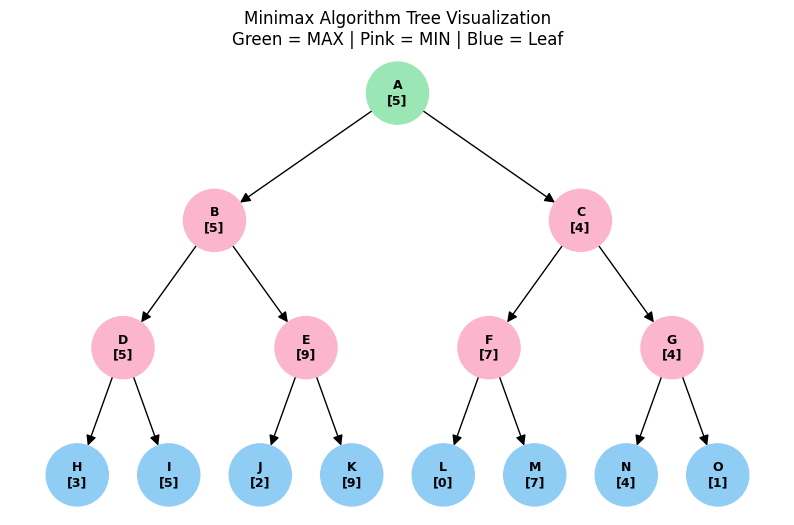

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

class MinimaxVisualizer:
    def __init__(self, tree, scores):
        self.tree = tree
        self.scores = scores
        self.graph = nx.DiGraph()
        self.labels = {}
        self.node_colors = {}
        
    def build_graph(self, node):
        """Recursively builds the NetworkX graph from the tree dictionary."""
        if node in self.tree:
            for child in self.tree[node]:
                self.graph.add_edge(node, child)
                self.build_graph(child)

    def minimax(self, node, depth, is_maximizing):
        """Standard Minimax algorithm that stores utility values for each node."""
        # Terminal node check (leaf node)
        if node not in self.tree or not self.tree[node]:
            return self.scores[node]

        if is_maximizing:
            best_val = float('-inf')
            for child in self.tree[node]:
                val = self.minimax(child, depth + 1, False)
                best_val = max(best_val, val)
            self.scores[node] = best_val
            return best_val
        else:
            best_val = float('inf')
            for child in self.tree[node]:
                val = self.minimax(child, depth + 1, True)
                best_val = min(best_val, val)
            self.scores[node] = best_val
            return best_val

    def visualize(self):
        """Computes positions and renders the Minimax tree."""
        # Build the graph and run Minimax
        self.build_graph('A')
        self.minimax('A', 0, True)

        # Generate hierarchy tree positions for matplotlib
        pos = self._hierarchy_pos(self.graph, 'A')

        # Node display labels (Name + Minimax score)
        node_labels = {node: f"{node}\n[{self.scores[node]}]" for node in self.graph.nodes()}

        # Assign colors: Maximizers (Green), Minimizers (Red), Leaves (Blue)
        color_map = []
        for node in self.graph.nodes():
            if node not in self.tree:  # Leaf
                color_map.append('#90cdf4')
            elif len(node) % 2 == 1 and node != 'A': # Alternating levels
                color_map.append('#fbb6ce')
            else:
                color_map.append('#9ae6b4')

        plt.figure(figsize=(10, 6))
        plt.title("Minimax Algorithm Tree Visualization\nGreen = MAX | Pink = MIN | Blue = Leaf", fontsize=12)

        nx.draw(
            self.graph, 
            pos, 
            with_labels=True, 
            labels=node_labels, 
            node_size=2000, 
            node_color=color_map, 
            font_size=9, 
            font_weight="bold", 
            arrowsize=15
        )
        
        plt.axis("off")
        plt.show()

    def _hierarchy_pos(self, G, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5):
        """Utility to calculate coordinates for tree layout visualization."""
        def _pos(node, left, right, vert_loc):
            pos[node] = ((left + right) / 2, vert_loc)
            children = list(G.neighbors(node))
            if children:
                dx = (right - left) / len(children)
                for i, child in enumerate(children):
                    _pos(child, left + i * dx, left + (i + 1) * dx, vert_loc - vert_gap)
        pos = {}
        _pos(root, 0, width, vert_loc)
        return pos


# --- Define Game Tree Structure ---
# Tree format: Parent -> [Children]
game_tree = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H', 'I'],
    'E': ['J', 'K'],
    'F': ['L', 'M'],
    'G': ['N', 'O']
}

# Leaf node terminal values (scores)
leaf_scores = {
    'H': 3, 'I': 5,
    'J': 2, 'K': 9,
    'L': 0, 'M': 7,
    'N': 4, 'O': 1
}

# Run program
viz = MinimaxVisualizer(game_tree, leaf_scores)
viz.visualize()